`Goal:`                                                                                                     
- Evaluate whether EfficientNet-B0 provides a stronger transfer-learning solution for magnetic-tile defect classification than our current ResNet18 configurations.

`Experiments:`

- E1 — Frozen EfficientNet-B0
- E2 — Partial Fine-Tuning EfficientNet-B0

Controlled factors:

- Same dataset
- Same train/validation/test split
- Same image resolution
- Same augmentation strategy
- Same balanced sampling strategy
- Same evaluation metrics
- Same untouched test set

In [38]:
import os
import random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from torchvision import transforms, models

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report,
)

import matplotlib.pyplot as plt

SEED = 42

IMAGE_SIZE = 224
NUM_CLASSES = 6

BATCH_SIZE = 32

CLASS_NAMES = [
    "MT_Blowhole",
    "MT_Break",
    "MT_Crack",
    "MT_Fray",
    "MT_Free",
    "MT_Uneven"
]

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

Device: cuda


In [10]:
random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

PROJECT_ROOT = Path.cwd().parent

DATASET_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "magnetic_tile"
)

print(DATASET_PATH)

d:\Study\industrial_visual_inspection\data\raw\magnetic_tile


In [11]:
image_paths = []
labels = []

for label, class_name in enumerate(CLASS_NAMES):

    image_folder = (
        DATASET_PATH
        / class_name
        / "Imgs"
    )

    paths = sorted(
        image_folder.glob("*.jpg")
    )

    image_paths.extend(paths)

    labels.extend(
        [label] * len(paths)
    )

print("Total images:", len(image_paths))

Total images: 1344


In [14]:
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    image_paths,
    labels,
    test_size=0.30,
    stratify=labels,
    random_state=SEED
)

val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths,
    temp_labels,
    test_size=0.50,
    stratify=temp_labels,
    random_state=SEED
)
print("Train:", len(train_paths))
print("Validation:", len(val_paths))
print("Test:", len(test_paths))

Train: 940
Validation: 202
Test: 202


**Make The Necessary Transformations For EfficientNet-B0**

In [17]:
train_transform = transforms.Compose([

    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),

    transforms.RandomHorizontalFlip(
        p=0.5
    ),

    transforms.RandomVerticalFlip(
        p=0.5
    ),

    transforms.RandomRotation(
        degrees=15
    ),

    transforms.Grayscale(
        num_output_channels=3
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[
            0.485,
            0.456,
            0.406
        ],
        std=[
            0.229,
            0.224,
            0.225
        ]
    )
])

val_test_transform = transforms.Compose([

    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),

    transforms.Grayscale(
        num_output_channels=3
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[
            0.485,
            0.456,
            0.406
        ],
        std=[
            0.229,
            0.224,
            0.225
        ]
    )
])

**Create Dataset Class and create dataloader objects using WeightedRandomSampler**

In [18]:
class MagneticTileDataset(Dataset):

    def __init__(
        self,
        image_paths,
        labels,
        transform=None
    ):

        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):

        return len(self.image_paths)

    def __getitem__(self, idx):

        image = Image.open(
            self.image_paths[idx]
        ).convert("L")

        label = self.labels[idx]

        if self.transform is not None:

            image = self.transform(image)

        return image, label


train_dataset = MagneticTileDataset(
    train_paths,
    train_labels,
    train_transform
)

val_dataset = MagneticTileDataset(
    val_paths,
    val_labels,
    val_test_transform
)

test_dataset = MagneticTileDataset(
    test_paths,
    test_labels,
    val_test_transform
)


train_class_counts = Counter(
    train_labels
)

sample_weights = torch.tensor(
    [
        1.0 / train_class_counts[label]
        for label in train_labels
    ],
    dtype=torch.double
)

train_sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(train_labels),
    replacement=True
)

# DataLoaders

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=train_sampler,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

images, labels = next(
    iter(train_loader)
)

print("Images:", images.shape)
print("Labels:", labels.shape)
print("Image dtype:", images.dtype)
print("Label dtype:", labels.dtype)

Images: torch.Size([32, 3, 224, 224])
Labels: torch.Size([32])
Image dtype: torch.float32
Label dtype: torch.int64


In [ ]:
# Load Pretrained Efficient Net Model
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

weights = EfficientNet_B0_Weights.DEFAULT

model = efficientnet_b0(weights=weights) #downloading EfficientNet-b0 model

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\Pradhuman/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 58.9MB/s]


In [21]:
# Look at the architecture
print(model)

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          

In [22]:
# Reusable Function for EfficientNet
def build_efficientnet(num_classes):
    
    weights = EfficientNet_B0_Weights.DEFAULT
    
    model = efficientnet_b0(weights=weights)
    
    # Replace ImageNet classifier
    in_features = model.classifier[1].in_features
    
    model.classifier[1] = nn.Linear(
        in_features,
        num_classes
    )
    
    return model

In [28]:
# Training the Model Function
def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    epochs,
    device,
    scheduler=None,
    save_path=None
):

    history = {
        "train_loss": [],
        "train_accuracy": [],
        "val_loss": [],
        "val_accuracy": [],
        "val_macro_f1": []
    }

    best_val_f1 = -np.inf

    for epoch in range(epochs):

        # =====================================================
        # Training
        # =====================================================

        model.train()

        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            running_loss += loss.item() * images.size(0)

            predictions = outputs.argmax(dim=1)

            correct += (
                predictions == labels
            ).sum().item()

            total += labels.size(0)

        train_loss = running_loss / total
        train_accuracy = correct / total


        # =====================================================
        # Validation
        # =====================================================

        model.eval()

        val_running_loss = 0.0
        val_correct = 0
        val_total = 0

        y_val_true = []
        y_val_pred = []

        with torch.no_grad():

            for images, labels in val_loader:

                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)

                loss = criterion(outputs, labels)

                val_running_loss += (
                    loss.item() * images.size(0)
                )

                predictions = outputs.argmax(dim=1)

                val_correct += (
                    predictions == labels
                ).sum().item()

                val_total += labels.size(0)

                y_val_true.extend(
                    labels.cpu().numpy()
                )

                y_val_pred.extend(
                    predictions.cpu().numpy()
                )

        val_loss = val_running_loss / val_total
        val_accuracy = val_correct / val_total

        val_macro_f1 = f1_score(
            y_val_true,
            y_val_pred,
            average="macro",
            zero_division=0
        )


        # =====================================================
        # Store history
        # =====================================================

        history["train_loss"].append(train_loss)
        history["train_accuracy"].append(train_accuracy)

        history["val_loss"].append(val_loss)
        history["val_accuracy"].append(val_accuracy)

        history["val_macro_f1"].append(val_macro_f1)


        # =====================================================
        # Save BEST Macro F1 model
        # =====================================================

        if val_macro_f1 > best_val_f1:

            best_val_f1 = val_macro_f1

            if save_path is not None:

                torch.save(
                    model.state_dict(),
                    save_path
                )


        # =====================================================
        # Scheduler
        # =====================================================

        if scheduler is not None:
            scheduler.step()


        # =====================================================
        # Progress
        # =====================================================

        print(
            f"Epoch [{epoch + 1}/{epochs}] | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_accuracy:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_accuracy:.4f} | "
            f"Val Macro F1: {val_macro_f1:.4f}"
        )

    print(
        f"\nBest Validation Macro F1: "
        f"{best_val_f1:.4f}"
    )

    return history

In [39]:
# Evaluate Model Function
def evaluate_model(
    model,
    test_loader,
    device,
    class_names
):

    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)

            outputs = model(images)

            predictions = outputs.argmax(dim=1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predictions.cpu().numpy())

    # Metrics
    accuracy = accuracy_score(y_true, y_pred)

    balanced_accuracy = balanced_accuracy_score(
        y_true,
        y_pred
    )

    precision = precision_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    macro_f1 = f1_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    mcc = matthews_corrcoef(
        y_true,
        y_pred
    )

    cm = confusion_matrix(
        y_true,
        y_pred
    )

    report = classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        zero_division=0
    )

    results = {
        "accuracy": accuracy,
        "balanced_accuracy": balanced_accuracy,
        "precision_macro": precision,
        "recall_macro": recall,
        "macro_f1": macro_f1,
        "mcc": mcc,
        "confusion_matrix": cm,
        "classification_report": report,
        "y_true": np.array(y_true),
        "y_pred": np.array(y_pred)
    }

    return results

In [29]:
# Visualization Function
def plot_training_history(history):

    epochs = range(1, len(history["train_loss"]) + 1)

    fig, axes = plt.subplots(
        1, 3,
        figsize=(18, 5)
    )

    # Loss
    axes[0].plot(
        epochs,
        history["train_loss"],
        label="Train Loss"
    )

    axes[0].plot(
        epochs,
        history["val_loss"],
        label="Validation Loss"
    )

    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    # Accuracy
    axes[1].plot(
        epochs,
        history["train_accuracy"],
        label="Train Accuracy"
    )

    axes[1].plot(
        epochs,
        history["val_accuracy"],
        label="Validation Accuracy"
    )

    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()

    # Macro F1
    axes[2].plot(
        epochs,
        history["val_macro_f1"],
        label="Validation Macro F1"
    )

    axes[2].set_title("Validation Macro F1")
    axes[2].set_xlabel("Epoch")
    axes[2].set_ylabel("Macro F1")
    axes[2].legend()

    plt.tight_layout()
    plt.show()

### 1. Frozen Feature Layers (Only Our Classifier Used)

In [30]:
model_frozen = build_efficientnet(
    num_classes=NUM_CLASSES
)

# Freeze EfficientNet feature extractor
for param in model_frozen.features.parameters():
    param.requires_grad = False

model_frozen = model_frozen.to(DEVICE)

In [31]:
total_params = sum(
    p.numel()
    for p in model_frozen.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model_frozen.parameters()
    if p.requires_grad
)

print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Frozen parameters:    {total_params - trainable_params:,}")

Total parameters:     4,015,234
Trainable parameters: 7,686
Frozen parameters:    4,007,548


In [32]:
# Define the Criterion and Optimizer
criterion = nn.CrossEntropyLoss()

optimizer_frozen = optim.AdamW(
    filter(
        lambda p: p.requires_grad,
        model_frozen.parameters()
    ),
    lr=1e-3,
    weight_decay=1e-4
)

In [34]:
# Let us now Train the Model
from pathlib import Path

MODEL_DIR = Path("../outputs/models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

frozen_checkpoint = (
    MODEL_DIR / "efficientnet_b0_frozen_best.pth"
)

history_frozen = train_model(
    model=model_frozen,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer_frozen,
    epochs=20,
    device=DEVICE,
    save_path=frozen_checkpoint
)

Epoch [1/20] | Train Loss: 1.6759 | Train Acc: 0.3202 | Val Loss: 1.5376 | Val Acc: 0.2871 | Val Macro F1: 0.1851
Epoch [2/20] | Train Loss: 1.4555 | Train Acc: 0.4979 | Val Loss: 1.4594 | Val Acc: 0.4059 | Val Macro F1: 0.3036
Epoch [3/20] | Train Loss: 1.2984 | Train Acc: 0.5702 | Val Loss: 1.4370 | Val Acc: 0.3020 | Val Macro F1: 0.2894
Epoch [4/20] | Train Loss: 1.1958 | Train Acc: 0.6000 | Val Loss: 1.3300 | Val Acc: 0.4010 | Val Macro F1: 0.3793
Epoch [5/20] | Train Loss: 1.1281 | Train Acc: 0.6394 | Val Loss: 1.4100 | Val Acc: 0.3317 | Val Macro F1: 0.3535
Epoch [6/20] | Train Loss: 1.0686 | Train Acc: 0.6532 | Val Loss: 1.3284 | Val Acc: 0.3960 | Val Macro F1: 0.3960
Epoch [7/20] | Train Loss: 1.0755 | Train Acc: 0.6511 | Val Loss: 1.3267 | Val Acc: 0.4257 | Val Macro F1: 0.4203
Epoch [8/20] | Train Loss: 1.0158 | Train Acc: 0.6585 | Val Loss: 1.1868 | Val Acc: 0.5050 | Val Macro F1: 0.4391
Epoch [9/20] | Train Loss: 0.9615 | Train Acc: 0.6777 | Val Loss: 1.1685 | Val Acc: 0.50

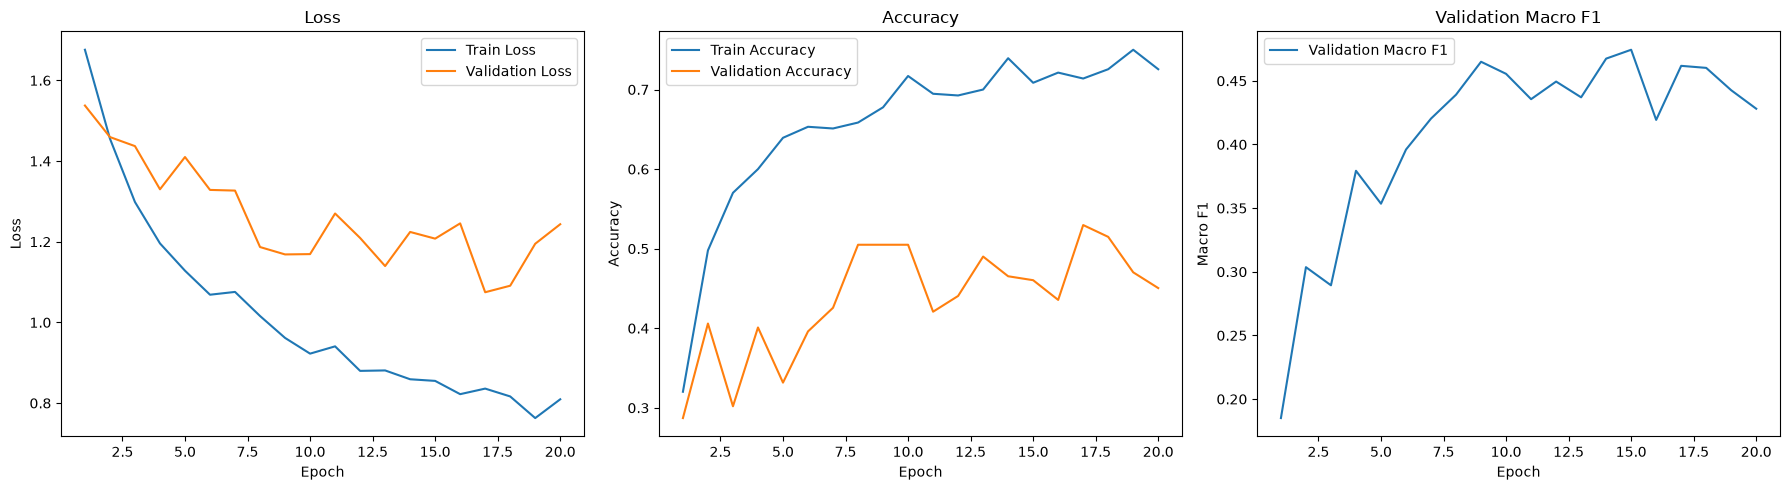

In [35]:
plot_training_history(history_frozen)

In [36]:
# Load the Best Epoch Value
model_frozen.load_state_dict(
    torch.load(
        frozen_checkpoint,
        map_location=DEVICE
    )
)

<All keys matched successfully>

In [40]:
# Evaluate on Test Dataloader
frozen_results = evaluate_model(
    model=model_frozen,
    test_loader=test_loader,
    device=DEVICE,
    class_names=CLASS_NAMES
)

In [42]:
print(
    f"Accuracy:          "
    f"{frozen_results['accuracy']:.4f}"
)

print(
    f"Balanced Accuracy: "
    f"{frozen_results['balanced_accuracy']:.4f}"
)

print(
    f"Macro Precision:   "
    f"{frozen_results['precision_macro']:.4f}"
)

print(
    f"Macro Recall:      "
    f"{frozen_results['recall_macro']:.4f}"
)

print(
    f"Macro F1:          "
    f"{frozen_results['macro_f1']:.4f}"
)

print(
    f"MCC:               "
    f"{frozen_results['mcc']:.4f}"
)

Accuracy:          0.4653
Balanced Accuracy: 0.6395
Macro Precision:   0.4468
Macro Recall:      0.6395
Macro F1:          0.4616
MCC:               0.3529


In [43]:
print(frozen_results["classification_report"])

              precision    recall  f1-score   support

 MT_Blowhole       0.28      0.72      0.40        18
    MT_Break       0.21      0.83      0.34        12
    MT_Crack       0.21      0.44      0.29         9
     MT_Fray       0.67      0.80      0.73         5
     MT_Free       0.93      0.37      0.53       143
   MT_Uneven       0.38      0.67      0.49        15

    accuracy                           0.47       202
   macro avg       0.45      0.64      0.46       202
weighted avg       0.75      0.47      0.50       202



In [44]:
frozen_summary = {
    "Model": "EfficientNet-B0 Frozen",
    "Accuracy": frozen_results["accuracy"],
    "Balanced Accuracy": frozen_results["balanced_accuracy"],
    "Macro Precision": frozen_results["precision_macro"],
    "Macro Recall": frozen_results["recall_macro"],
    "Macro F1": frozen_results["macro_f1"],
    "MCC": frozen_results["mcc"],
}

frozen_summary

{'Model': 'EfficientNet-B0 Frozen',
 'Accuracy': 0.46534653465346537,
 'Balanced Accuracy': 0.6395493395493396,
 'Macro Precision': 0.44683243843378223,
 'Macro Recall': 0.6395493395493396,
 'Macro F1': 0.4616291569805418,
 'MCC': 0.35286358569356646}

| Model                  |   Accuracy | Balanced Acc. |   Macro F1 |        MCC |
| ---------------------- | ---------: | ------------: | ---------: | ---------: |
| ResNet18 Partial FT    | **93.56%** |    **87.50%** | **87.45%** | **0.8636** |
| EfficientNet-B0 Frozen |     46.53% |        63.95% |     46.16% |     0.3529 |


### 2. Partial Fine-Tuning EfficientNet-B0 

In [46]:
model_partial = build_efficientnet(
    num_classes=NUM_CLASSES
)

for param in model_partial.features.parameters():
    param.requires_grad = False

for param in model_partial.features[-2:].parameters(): # We will unfreeze only the last 2 Feature layers for partial fine-tuning
    param.requires_grad = True

total_params = sum(
    p.numel()
    for p in model_partial.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model_partial.parameters()
    if p.requires_grad
)

print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Frozen parameters:    {total_params - trainable_params:,}")

Total parameters:     4,015,234
Trainable parameters: 1,137,078
Frozen parameters:    2,878,156


In [49]:
# Verification 

for i, block in enumerate(model_partial.features):
    
    trainable = any(
        p.requires_grad
        for p in block.parameters()
    )
    
    print(
        f"Block {i}: "
        f"{'TRAINABLE' if trainable else 'FROZEN'}"
    )

model_partial = model_partial.to(DEVICE)

Block 0: FROZEN
Block 1: FROZEN
Block 2: FROZEN
Block 3: FROZEN
Block 4: FROZEN
Block 5: FROZEN
Block 6: FROZEN
Block 7: TRAINABLE
Block 8: TRAINABLE


In [50]:
# Loss and Optimizer
criterion = nn.CrossEntropyLoss()

optimizer_partial = optim.AdamW(
    filter(
        lambda p: p.requires_grad,
        model_partial.parameters()
    ),
    lr=1e-4,
    weight_decay=1e-4
)

In [51]:
# Train the Model
partial_checkpoint = (
    MODEL_DIR / "efficientnet_b0_partial_ft_best.pth"
)

history_partial = train_model(
    model=model_partial,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer_partial,
    epochs=20,
    device=DEVICE,
    save_path=partial_checkpoint
)

Epoch [1/20] | Train Loss: 1.7555 | Train Acc: 0.2394 | Val Loss: 1.7327 | Val Acc: 0.2475 | Val Macro F1: 0.2119
Epoch [2/20] | Train Loss: 1.5896 | Train Acc: 0.4521 | Val Loss: 1.6630 | Val Acc: 0.2772 | Val Macro F1: 0.2781
Epoch [3/20] | Train Loss: 1.4431 | Train Acc: 0.5415 | Val Loss: 1.5965 | Val Acc: 0.2723 | Val Macro F1: 0.3111
Epoch [4/20] | Train Loss: 1.3115 | Train Acc: 0.5745 | Val Loss: 1.5847 | Val Acc: 0.2525 | Val Macro F1: 0.3112
Epoch [5/20] | Train Loss: 1.1941 | Train Acc: 0.6383 | Val Loss: 1.5477 | Val Acc: 0.2673 | Val Macro F1: 0.3277
Epoch [6/20] | Train Loss: 1.1026 | Train Acc: 0.6723 | Val Loss: 1.4874 | Val Acc: 0.2921 | Val Macro F1: 0.3430
Epoch [7/20] | Train Loss: 1.0125 | Train Acc: 0.6809 | Val Loss: 1.4177 | Val Acc: 0.3713 | Val Macro F1: 0.4160
Epoch [8/20] | Train Loss: 0.9069 | Train Acc: 0.7223 | Val Loss: 1.4219 | Val Acc: 0.3366 | Val Macro F1: 0.4059
Epoch [9/20] | Train Loss: 0.8009 | Train Acc: 0.7553 | Val Loss: 1.3620 | Val Acc: 0.40

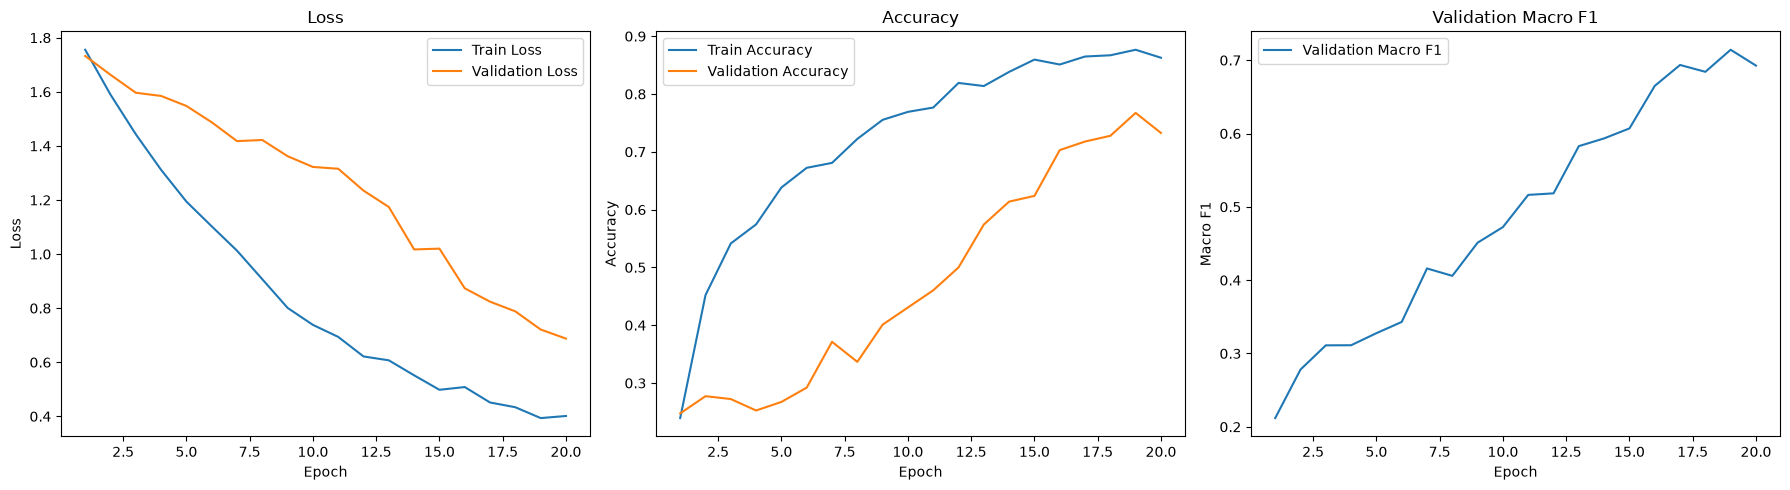

In [52]:
plot_training_history(history_partial)

In [53]:
# Load the best model
model_partial.load_state_dict(
    torch.load(
        partial_checkpoint,
        map_location=DEVICE
    )
)

<All keys matched successfully>

In [54]:
# Final test evaluation
partial_results = evaluate_model(
    model=model_partial,
    test_loader=test_loader,
    device=DEVICE,
    class_names=CLASS_NAMES
)

In [55]:
partial_summary = {
    "Model": "EfficientNet-B0 Partial FT",
    "Accuracy": partial_results["accuracy"],
    "Balanced Accuracy": partial_results["balanced_accuracy"],
    "Macro Precision": partial_results["precision_macro"],
    "Macro Recall": partial_results["recall_macro"],
    "Macro F1": partial_results["macro_f1"],
    "MCC": partial_results["mcc"],
}

partial_summary

{'Model': 'EfficientNet-B0 Partial FT',
 'Accuracy': 0.6881188118811881,
 'Balanced Accuracy': 0.7606902356902356,
 'Macro Precision': 0.6145125008954796,
 'Macro Recall': 0.7606902356902356,
 'Macro F1': 0.626528955115453,
 'MCC': 0.5516902482035094}

In [56]:
print(partial_results["classification_report"])

              precision    recall  f1-score   support

 MT_Blowhole       0.44      0.89      0.59        18
    MT_Break       0.41      0.75      0.53        12
    MT_Crack       0.32      0.89      0.47         9
     MT_Fray       1.00      0.60      0.75         5
     MT_Free       0.97      0.64      0.77       143
   MT_Uneven       0.55      0.80      0.65        15

    accuracy                           0.69       202
   macro avg       0.61      0.76      0.63       202
weighted avg       0.83      0.69      0.72       202



In [57]:
print(partial_results["confusion_matrix"])

[[16  2  0  0  0  0]
 [ 0  9  1  0  2  0]
 [ 0  1  8  0  0  0]
 [ 0  1  1  3  0  0]
 [20  7 15  0 91 10]
 [ 0  2  0  0  1 12]]


| Model                          |   Accuracy | Balanced Accuracy |   Macro F1 |       MCC |
| ------------------------------ | ---------: | ----------------: | ---------: | --------: |
| EfficientNet-B0 Frozen         |     46.53% |            63.95% |     46.16% |     0.353 |
| **EfficientNet-B0 Partial FT** | **68.81%** |        **76.07%** | **62.65%** | **0.552** |
| **ResNet18 Partial FT**        | **93.56%** |        **87.50%** | **87.45%** | **0.864** |

Our EfficientNet experiment has answered an important question:

EfficientNet-B0 can adapt to the magnetic-tile domain, but with our current partial fine-tuning configuration it does not outperform ResNet18.

`Final Summary`
| Model                      |   Accuracy | Balanced Accuracy |   Macro F1 |       MCC |
| -------------------------- | ---------: | ----------------: | ---------: | --------: |
| Complex CNN + Optuna       |     89.11% |            69.51% |     72.68% |     0.765 |
| ResNet18 Frozen            |     59.90% |            58.77% |     47.77% |     0.368 |
| ResNet18 Full FT           |     86.14% |            86.03% |     76.76% |     0.742 |
| **ResNet18 Partial FT**    | **93.56%** |        **87.50%** | **87.45%** | **0.864** |
| EfficientNet-B0 Frozen     |     46.53% |            63.95% |     46.16% |     0.353 |
| EfficientNet-B0 Partial FT |     68.81% |            76.07% |     62.65% |     0.552 |
